# 08. Community Rerank Stability

## 1. 분석 목적

이번 분석에서는 새로운 Feature를 추가하지 않고 다음 다섯 질문을 검증한다.

1. Base TOP 200 Candidate는 실제 Relevant Item을 충분히 포함하는가?
2. Candidate Pool을 늘리거나 줄이면 최종 추천 성능이 어떻게 변하는가?
3. gamma=0.5보다 Community 비중을 더 높이면 성능이 계속 개선되는가?
4. 현재 gamma=0.5 결과가 탐색 범위 경계 때문에 선택된 것은 아닌가?
5. 성능 개선과 계산량을 함께 고려했을 때 적절한 Candidate Pool은 어느 정도인가?

고정하는 요소:

- Raw Accord Cosine
- IDF Weighted Union Note Jaccard
- Accord : Note = 0.5 : 0.5
- Season + Daypart Community Similarity
- Reliable vote `>=20`
- Community share 계산 방법
- Relevant Pair 기준과 Development / Final Holdout split

새로운 Feature, LLM, Embedding, 머신러닝, Note Tier, Accord IDF, Popularity score는 추가하지 않는다. Popularity는 robustness 그룹 구분에만 사용한다. `reminds_me_of`는 평가 label로만 사용한다.

## 2. 환경 설정

In [1]:
import array
import collections
import gc
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import sparse
from tqdm import tqdm

SEED = 42
N_FOLDS = 5
BATCH_SIZE = 8
MAX_CANDIDATES = 1000
CANDIDATE_POOLS = np.array([50, 100, 200, 500, 1000])
GAMMAS = np.round(np.arange(0.0, 1.001, 0.05), 2)
TOP_KS = (10, 20)
BOOTSTRAP_RESAMPLES = 2000
PRACTICAL_TOLERANCE = 0.002
SEASON_NAMES = ("winter", "spring", "summer", "autumn")
DAYPART_NAMES = ("day", "night")

jsonl_path = pathlib.Path.cwd() / "perfumes.jsonl"
assert jsonl_path.is_file(), f"파일을 찾을 수 없습니다: {jsonl_path}"
print(f"데이터: {jsonl_path.name} ({jsonl_path.stat().st_size / (1024 ** 2):,.2f} MB)")

데이터: perfumes.jsonl (485.94 MB)


## 3. 데이터 로드

In [2]:
perfume_ids = array.array("i")
perfume_names, perfume_brands = [], []
popularity_values = array.array("f")
has_accord, has_note = array.array("b"), array.array("b")

accord_to_col = {}
accord_rows, accord_cols, accord_data = array.array("I"), array.array("I"), array.array("f")
note_to_col = {}
note_rows, note_cols = array.array("I"), array.array("I")
season_vote_rows, daypart_vote_rows = [], []

relation_source_ids, relation_target_ids = array.array("i"), array.array("i")
relation_up_votes, relation_down_votes = array.array("i"), array.array("i")

with jsonl_path.open("r", encoding="utf-8") as file:
    for line in tqdm(file, desc="JSONL load", unit=" perfumes", mininterval=2.0):
        if not line.strip():
            continue
        row_index = len(perfume_ids)
        record = json.loads(line)
        perfume_id = int(record["id"])
        perfume_ids.append(perfume_id)
        perfume_names.append(record.get("name") or "")
        perfume_brands.append(record.get("brand") or "")

        magnitude = (record.get("popularity") or {}).get("magnitude")
        popularity_values.append(float(magnitude) if magnitude is not None else np.nan)

        accord_strengths = {}
        for item in record.get("accords") or []:
            name, strength = item.get("name"), item.get("strength")
            if name and strength is not None:
                col = accord_to_col.setdefault(name, len(accord_to_col))
                accord_strengths[col] = float(strength)
        has_accord.append(bool(accord_strengths))
        for col, strength in accord_strengths.items():
            accord_rows.append(row_index)
            accord_cols.append(col)
            accord_data.append(strength)

        notes = record.get("notes") or {}
        tiered = notes.get("tiered") or {}
        note_names = set()
        for position in ("top", "middle", "base"):
            note_names.update(
                item.get("name") for item in tiered.get(position) or [] if item.get("name")
            )
        note_names.update(item.get("name") for item in notes.get("flat") or [] if item.get("name"))
        has_note.append(bool(note_names))
        for name in note_names:
            note_rows.append(row_index)
            note_cols.append(note_to_col.setdefault(name, len(note_to_col)))

        seasons = record.get("seasons") or {}
        season_vote_rows.append([int(seasons.get(name, 0) or 0) for name in SEASON_NAMES])
        daypart = record.get("daypart") or {}
        daypart_vote_rows.append([int(daypart.get(name, 0) or 0) for name in DAYPART_NAMES])

        for relation in (record.get("similar") or {}).get("reminds_me_of") or []:
            target_id = relation.get("id")
            up_votes, down_votes = relation.get("up_votes"), relation.get("down_votes")
            relation_source_ids.append(perfume_id)
            relation_target_ids.append(int(target_id) if target_id is not None else -1)
            relation_up_votes.append(int(up_votes) if up_votes is not None else -1)
            relation_down_votes.append(int(down_votes) if down_votes is not None else -1)

perfume_ids = np.asarray(perfume_ids, dtype=np.int32)
popularity = np.asarray(popularity_values, dtype=np.float32)
has_accord = np.asarray(has_accord, dtype=bool)
has_note = np.asarray(has_note, dtype=bool)
season_votes = np.asarray(season_vote_rows, dtype=np.int32)
daypart_votes = np.asarray(daypart_vote_rows, dtype=np.int32)
id_to_row = {int(perfume_id): row for row, perfume_id in enumerate(perfume_ids)}
n_perfumes = len(perfume_ids)

print(f"향수 수: {n_perfumes:,}")
print(f"고유 Accord 수: {len(accord_to_col):,}")
print(f"고유 Union Note 수: {len(note_to_col):,}")
print(f"directed reminds_me_of 수: {len(relation_source_ids):,}")
assert len(accord_to_col) == 92

JSONL load: 0 perfumes [00:00, ? perfumes/s]

JSONL load: 131930 perfumes [00:09, 13887.15 perfumes/s]

향수 수: 131,930
고유 Accord 수: 92
고유 Union Note 수: 2,523
directed reminds_me_of 수: 692,729


## 4. 평가 데이터 재현

In [ ]:
directed_relations = pd.DataFrame({
    "source_id": np.asarray(relation_source_ids, dtype=np.int32),
    "target_id": np.asarray(relation_target_ids, dtype=np.int32),
    "up_votes": np.asarray(relation_up_votes, dtype=np.int32),
    "down_votes": np.asarray(relation_down_votes, dtype=np.int32),
})
valid = directed_relations[
    (directed_relations["source_id"] > 0)
    & (directed_relations["target_id"] > 0)
    & (directed_relations["up_votes"] >= 0)
    & (directed_relations["down_votes"] >= 0)
].copy()
valid["pair_low"] = np.minimum(valid["source_id"], valid["target_id"])
valid["pair_high"] = np.maximum(valid["source_id"], valid["target_id"])
pair_relations = valid.groupby(["pair_low", "pair_high"], sort=False, as_index=False)[
    ["up_votes", "down_votes"]
].sum()
pair_relations["total_votes"] = pair_relations["up_votes"] + pair_relations["down_votes"]
pair_relations["agree_ratio"] = np.divide(
    pair_relations["up_votes"], pair_relations["total_votes"],
    out=np.full(len(pair_relations), np.nan),
    where=pair_relations["total_votes"].to_numpy() > 0,
)
relevant_pairs_all = pair_relations[
    (pair_relations["pair_low"] != pair_relations["pair_high"])
    & (pair_relations["total_votes"] >= 20)
    & (pair_relations["agree_ratio"] >= 0.8)
].copy()
inside_mask = (
    relevant_pairs_all["pair_low"].isin(id_to_row)
    & relevant_pairs_all["pair_high"].isin(id_to_row)
)
relevant_pairs = relevant_pairs_all.loc[inside_mask].copy()

relevant_by_query = collections.defaultdict(set)
for low, high in relevant_pairs[["pair_low", "pair_high"]].itertuples(index=False, name=None):
    low, high = int(low), int(high)
    relevant_by_query[low].add(high)
    relevant_by_query[high].add(low)

eligible_query_ids = np.array(sorted(
    query_id for query_id, items in relevant_by_query.items()
    if len(items) >= 2 and has_accord[id_to_row[query_id]] and has_note[id_to_row[query_id]]
), dtype=np.int32)
selection_rng = np.random.default_rng(SEED)
selected_query_ids = selection_rng.choice(eligible_query_ids, size=1000, replace=False)
split_rng = np.random.default_rng(SEED)
selected_query_ids = split_rng.permutation(selected_query_ids)
development_query_ids = selected_query_ids[:700]
final_holdout_query_ids = selected_query_ids[700:]

expected_development_head = [68393, 93820, 40155, 16220, 109598, 57684, 5634, 19669, 48389, 71291]
expected_holdout_head = [40468, 8894, 1658, 51250, 12112, 55166, 85084, 113714, 87451, 33253]
assert development_query_ids[:10].tolist() == expected_development_head
assert final_holdout_query_ids[:10].tolist() == expected_holdout_head
assert len(development_query_ids) == 700 and len(final_holdout_query_ids) == 300
assert set(development_query_ids).isdisjoint(final_holdout_query_ids)

display(pd.Series({
    "Relevant Pair 수": len(relevant_pairs_all),
    "평가 가능 Query 수": len(eligible_query_ids),
    "Development 수": len(development_query_ids),
    "Final Holdout 수": len(final_holdout_query_ids),
}).to_frame("값"))
print("Development ID 앞 10개:", development_query_ids[:10].tolist())
print("Holdout ID 앞 10개:", final_holdout_query_ids[:10].tolist())
print("07 Notebook과 동일한 split임을 assert로 확인했습니다.")
print("Final Holdout은 아래의 candidate/평가 함수에 전달하지 않습니다.")

del directed_relations, valid, pair_relations, relevant_pairs, relevant_pairs_all
del relation_source_ids, relation_target_ids, relation_up_votes, relation_down_votes
gc.collect()

,값
Relevant Pair 수,10770
평가 가능 Query 수,3835
Development 수,700
Final Holdout 수,300


Development ID 앞 10개: [68393, 93820, 40155, 16220, 109598, 57684, 5634, 19669, 48389, 71291]
Holdout ID 앞 10개: [40468, 8894, 1658, 51250, 12112, 55166, 85084, 113714, 87451, 33253]
07 Notebook과 동일한 split임을 assert로 확인했습니다.
Final Holdout은 아래의 candidate/평가 함수에 전달하지 않습니다.


0

## 5. Development 5-Fold와 Community Share 재현

In [4]:
cv_rng = np.random.default_rng(SEED)
cv_permuted = cv_rng.permutation(development_query_ids)
cv_folds = [part.astype(np.int32, copy=False) for part in np.array_split(cv_permuted, N_FOLDS)]
development_rows = np.array([id_to_row[int(q)] for q in development_query_ids], dtype=np.int32)
assert [len(fold) for fold in cv_folds] == [140] * 5

season_totals = season_votes.sum(axis=1).astype(np.int32)
daypart_totals = daypart_votes.sum(axis=1).astype(np.int32)
season_shares = np.full((n_perfumes, 4), np.nan, dtype=np.float32)
daypart_shares = np.full((n_perfumes, 2), np.nan, dtype=np.float32)
valid_season = season_totals > 0
valid_daypart = daypart_totals > 0
season_shares[valid_season] = season_votes[valid_season] / season_totals[valid_season, None]
daypart_shares[valid_daypart] = daypart_votes[valid_daypart] / daypart_totals[valid_daypart, None]

season_unit = np.full_like(season_shares, np.nan)
daypart_unit = np.full_like(daypart_shares, np.nan)
season_unit[valid_season] = season_shares[valid_season] / np.linalg.norm(
    season_shares[valid_season], axis=1
)[:, None]
daypart_unit[valid_daypart] = daypart_shares[valid_daypart] / np.linalg.norm(
    daypart_shares[valid_daypart], axis=1
)[:, None]

assert np.allclose(season_shares[valid_season].sum(axis=1), 1.0)
assert np.allclose(daypart_shares[valid_daypart].sum(axis=1), 1.0)
print("Season / Daypart는 07과 동일한 share 및 cosine 표현을 사용합니다.")
print("Reliable-vote 기준은 두 향수의 해당 total이 모두 20 이상인 경우입니다.")

Season / Daypart는 07과 동일한 share 및 cosine 표현을 사용합니다.
Reliable-vote 기준은 두 향수의 해당 total이 모두 20 이상인 경우입니다.


## 6. Base TOP 1000 생성과 현재 Base Model 재현

In [5]:
def binary_csr(rows, cols, shape):
    matrix = sparse.csr_matrix(
        (np.ones(len(rows), dtype=np.float32),
         (np.asarray(rows, dtype=np.int32), np.asarray(cols, dtype=np.int32))),
        shape=shape, dtype=np.float32,
    )
    matrix.sum_duplicates()
    matrix.data[:] = 1.0
    return matrix

def row_normalize(matrix):
    norms = np.sqrt(matrix.multiply(matrix).sum(axis=1)).A1.astype(np.float32)
    inverse = np.zeros_like(norms)
    np.divide(1.0, norms, out=inverse, where=norms > 0)
    return matrix.multiply(inverse[:, None]).tocsr()

def top_k_rows(score_vector, k):
    scores = np.nan_to_num(np.asarray(score_vector), nan=-np.inf)
    preliminary = np.argpartition(-scores, kth=k - 1)[:k]
    threshold = scores[preliminary].min()
    higher = np.flatnonzero(scores > threshold)
    tied = np.flatnonzero(scores == threshold)
    needed = k - len(higher)
    if needed < len(tied):
        tied = tied[np.argpartition(perfume_ids[tied], needed - 1)[:needed]]
    selected = np.concatenate([higher, tied[:needed]])
    order = np.lexsort((perfume_ids[selected], -scores[selected]))
    return selected[order].astype(np.int32, copy=False)

X_accord_raw = sparse.csr_matrix(
    (np.asarray(accord_data, dtype=np.float32),
     (np.asarray(accord_rows, dtype=np.int32), np.asarray(accord_cols, dtype=np.int32))),
    shape=(n_perfumes, len(accord_to_col)), dtype=np.float32,
)
X_notes = binary_csr(note_rows, note_cols, (n_perfumes, len(note_to_col)))
X_accord = row_normalize(X_accord_raw)
note_df = np.asarray(X_notes.sum(axis=0)).ravel().astype(np.int32)
note_idf = (np.log((n_perfumes + 1) / (note_df + 1)) + 1).astype(np.float32)
X_note_weighted = X_notes.multiply(note_idf).tocsr()
note_weight_sums = np.asarray(X_note_weighted.sum(axis=1)).ravel().astype(np.float32)

base_top_1000 = {}
base_top_1000_scores = {}
for start in tqdm(range(0, len(development_query_ids), BATCH_SIZE), desc="Base TOP 1000", mininterval=2.0):
    query_ids = development_query_ids[start:start + BATCH_SIZE]
    query_rows = np.array([id_to_row[int(q)] for q in query_ids], dtype=np.int32)
    accord_scores = (X_accord[query_rows] @ X_accord.T).toarray().astype(np.float32, copy=False)
    intersection = (X_note_weighted[query_rows] @ X_notes.T).toarray()
    union = note_weight_sums[query_rows, None] + note_weight_sums[None, :] - intersection
    note_scores = np.zeros(intersection.shape, dtype=np.float32)
    np.divide(intersection, union, out=note_scores, where=union > 0)
    base_scores = 0.5 * accord_scores + 0.5 * note_scores

    for i, (query_id, query_row) in enumerate(zip(query_ids, query_rows)):
        query_id, query_row = int(query_id), int(query_row)
        base_scores[i, query_row] = -np.inf
        rows = top_k_rows(base_scores[i], MAX_CANDIDATES)
        base_top_1000[query_id] = rows
        base_top_1000_scores[query_id] = base_scores[i, rows].copy()
    del accord_scores, intersection, union, note_scores, base_scores

print(f"Base TOP 1000 생성 query 수: {len(base_top_1000):,}")
print(f"Final Holdout candidate 생성 수: {sum(int(q) in base_top_1000 for q in final_holdout_query_ids)}")
assert len(base_top_1000) == 700
assert not any(int(q) in base_top_1000 for q in final_holdout_query_ids)

del X_accord_raw, accord_rows, accord_cols, accord_data, note_rows, note_cols
gc.collect()


Base TOP 1000:   0%|          | 0/88 [00:00<?, ?it/s]


Base TOP 1000:  36%|███▋      | 32/88 [00:02<00:03, 15.79it/s]


Base TOP 1000:  73%|███████▎  | 64/88 [00:04<00:01, 15.26it/s]


Base TOP 1000: 100%|██████████| 88/88 [00:05<00:00, 15.46it/s]

Base TOP 1000 생성 query 수: 700
Final Holdout candidate 생성 수: 0


0

Base TOP 1000은 각 Development query에 대해 한 번만 생성하고 이후 모든 Candidate Pool 실험에서 prefix를 재사용한다. 전체 `131,930 × 131,930` matrix는 만들지 않는다.

## 7. 평가 함수와 Base 성능

In [6]:
def query_metrics(recommended_rows, relevant_ids, k):
    recommended_ids = perfume_ids[recommended_rows[:k]]
    relevance = np.fromiter(
        (int(candidate_id) in relevant_ids for candidate_id in recommended_ids),
        dtype=np.int8, count=len(recommended_ids),
    )
    hits = int(relevance.sum())
    positions = np.flatnonzero(relevance)
    discounts = 1.0 / np.log2(np.arange(2, len(relevance) + 2))
    ideal_length = min(len(relevant_ids), k)
    idcg = float(discounts[:ideal_length].sum())
    return {
        f"Recall@{k}": hits / len(relevant_ids),
        f"HitRate@{k}": float(hits > 0),
        f"MRR@{k}": 1.0 / (positions[0] + 1) if positions.size else 0.0,
        f"NDCG@{k}": float(np.dot(relevance, discounts)) / idcg if idcg > 0 else 0.0,
    }

def per_query_table(rankings):
    rows = []
    for query_id in development_query_ids:
        query_id = int(query_id)
        row = {"query_id": query_id}
        for k in TOP_KS:
            row.update(query_metrics(rankings[query_id], relevant_by_query[query_id], k))
        rows.append(row)
    return pd.DataFrame(rows)

REPORT_METRICS = ["Recall@10", "HitRate@10", "MRR@10", "NDCG@10", "Recall@20", "NDCG@20"]

def fold_summary(detail):
    fold_rows = []
    for fold_number, fold_ids in enumerate(cv_folds, start=1):
        part = detail[detail["query_id"].isin(fold_ids)]
        fold_rows.append({"fold": fold_number, **{metric: part[metric].mean() for metric in REPORT_METRICS}})
    fold_df = pd.DataFrame(fold_rows)
    means = {metric: fold_df[metric].mean() for metric in REPORT_METRICS}
    stds = {metric: fold_df[metric].std(ddof=1) for metric in REPORT_METRICS}
    return fold_df, means, stds

base_rankings = {int(q): base_top_1000[int(q)][:20] for q in development_query_ids}
base_per_query = per_query_table(base_rankings)
base_fold_df, base_means, base_stds = fold_summary(base_per_query)
display(pd.DataFrame([{metric: base_means[metric] for metric in REPORT_METRICS}]).round(4))
print(f"07 Baseline NDCG@10 0.2709와 차이: {base_means['NDCG@10'] - 0.2709:+.6f}")
print("Final Holdout 평가 query 수: 0")

,Recall@10,HitRate@10,MRR@10,NDCG@10,Recall@20,NDCG@20
0,0.301,0.5657,0.3813,0.2709,0.35,0.2886


07 Baseline NDCG@10 0.2709와 차이: -0.000006
Final Holdout 평가 query 수: 0


## 8. Candidate Retrieval Ceiling

In [7]:
ceiling_rows = []
for pool in CANDIDATE_POOLS:
    recalls, hits = [], []
    for query_id in development_query_ids:
        query_id = int(query_id)
        candidate_ids = set(map(int, perfume_ids[base_top_1000[query_id][:pool]]))
        relevant_ids = relevant_by_query[query_id]
        found = len(candidate_ids & relevant_ids)
        recalls.append(found / len(relevant_ids))
        hits.append(float(found > 0))
    ceiling_rows.append({
        "candidate_pool": int(pool),
        "CandidateRecall": np.mean(recalls),
        "CandidateHitRate": np.mean(hits),
    })
candidate_ceiling_df = pd.DataFrame(ceiling_rows)
display(candidate_ceiling_df.round(4))

recall_increase_df = pd.DataFrame({
    "transition": ["50 → 100", "100 → 200", "200 → 500", "500 → 1000"],
    "CandidateRecall increase": np.diff(candidate_ceiling_df["CandidateRecall"]),
})
display(recall_increase_df.round(4))

,candidate_pool,CandidateRecall,CandidateHitRate
0,50,0.4151,0.6686
1,100,0.4592,0.7157
2,200,0.5118,0.7571
3,500,0.5806,0.8214
4,1000,0.6240,0.8486


,transition,CandidateRecall increase
0,50 → 100,0.0440
1,100 → 200,0.0526
2,200 → 500,0.0688
3,500 → 1000,0.0435


## 9. Candidate Pool별 Reranking Oracle Upper Bound

In [8]:
oracle_rows = []
for pool in CANDIDATE_POOLS:
    oracle_rankings = {}
    for query_id in development_query_ids:
        query_id = int(query_id)
        candidates = base_top_1000[query_id][:pool]
        relevant_ids = relevant_by_query[query_id]
        is_relevant = np.array([int(perfume_ids[row]) in relevant_ids for row in candidates])
        oracle_rankings[query_id] = np.concatenate([candidates[is_relevant], candidates[~is_relevant]])[:20]
    detail = per_query_table(oracle_rankings)
    oracle_rows.append({
        "candidate_pool": int(pool),
        "Oracle Recall@10": detail["Recall@10"].mean(),
        "Oracle HitRate@10": detail["HitRate@10"].mean(),
        "Oracle NDCG@10": detail["NDCG@10"].mean(),
    })
oracle_df = pd.DataFrame(oracle_rows)
display(oracle_df.round(4))
display(Markdown(
    "Oracle은 실제 추천 모델이 아니다. Candidate Pool 안에 이미 포함된 Relevant Item을 모두 위로 올렸을 때의 "
    "이론적 reranking 상한이다."
))

,candidate_pool,Oracle Recall@10,Oracle HitRate@10,Oracle NDCG@10
0,50,0.4151,0.6686,0.4798
1,100,0.4585,0.7157,0.5246
2,200,0.5103,0.7571,0.5752
3,500,0.5781,0.8214,0.6428
4,1000,0.6212,0.8486,0.6833


Oracle은 실제 추천 모델이 아니다. Candidate Pool 안에 이미 포함된 Relevant Item을 모두 위로 올렸을 때의 이론적 reranking 상한이다.

## 10. Reliable Community Similarity 재현

In [9]:
def reliable_community_for_candidates(query_row, candidate_rows):
    candidate_rows = np.asarray(candidate_rows, dtype=np.int32)
    season_similarity = np.full(len(candidate_rows), np.nan, dtype=np.float32)
    daypart_similarity = np.full(len(candidate_rows), np.nan, dtype=np.float32)

    season_ok = (season_totals[query_row] >= 20) & (season_totals[candidate_rows] >= 20)
    daypart_ok = (daypart_totals[query_row] >= 20) & (daypart_totals[candidate_rows] >= 20)
    if season_ok.any():
        season_similarity[season_ok] = season_unit[candidate_rows[season_ok]] @ season_unit[query_row]
    if daypart_ok.any():
        daypart_similarity[daypart_ok] = daypart_unit[candidate_rows[daypart_ok]] @ daypart_unit[query_row]

    combined = np.full(len(candidate_rows), np.nan, dtype=np.float32)
    both = np.isfinite(season_similarity) & np.isfinite(daypart_similarity)
    season_only = np.isfinite(season_similarity) & ~np.isfinite(daypart_similarity)
    daypart_only = ~np.isfinite(season_similarity) & np.isfinite(daypart_similarity)
    combined[both] = 0.5 * season_similarity[both] + 0.5 * daypart_similarity[both]
    combined[season_only] = season_similarity[season_only]
    combined[daypart_only] = daypart_similarity[daypart_only]
    return season_similarity, daypart_similarity, combined

season_available = {}
daypart_available = {}
community_top_1000 = {}
for query_id in development_query_ids:
    query_id = int(query_id)
    query_row = id_to_row[query_id]
    season_sim, daypart_sim, combined = reliable_community_for_candidates(
        query_row, base_top_1000[query_id]
    )
    season_available[query_id] = np.isfinite(season_sim)
    daypart_available[query_id] = np.isfinite(daypart_sim)
    community_top_1000[query_id] = combined

print("Season + Daypart Reliable-vote >=20 Community Similarity를 TOP 1000에 캐시했습니다.")
print("둘 다 missing인 Candidate는 NaN이며 reranking에서 Base score를 유지합니다.")

Season + Daypart Reliable-vote >=20 Community Similarity를 TOP 1000에 캐시했습니다.
둘 다 missing인 Candidate는 NaN이며 reranking에서 Base score를 유지합니다.


## 11. Score Scale 진단

,score,count,mean,std,min,10%,25%,median,75%,90%,max
0,Base Similarity,140000,0.5310,0.0758,0.3223,0.4562,0.4868,0.5203,0.5587,0.6092,1.0
1,Community Similarity (available only),66566,0.9374,0.0803,0.2509,0.8405,0.9211,0.9675,0.9872,0.9948,1.0


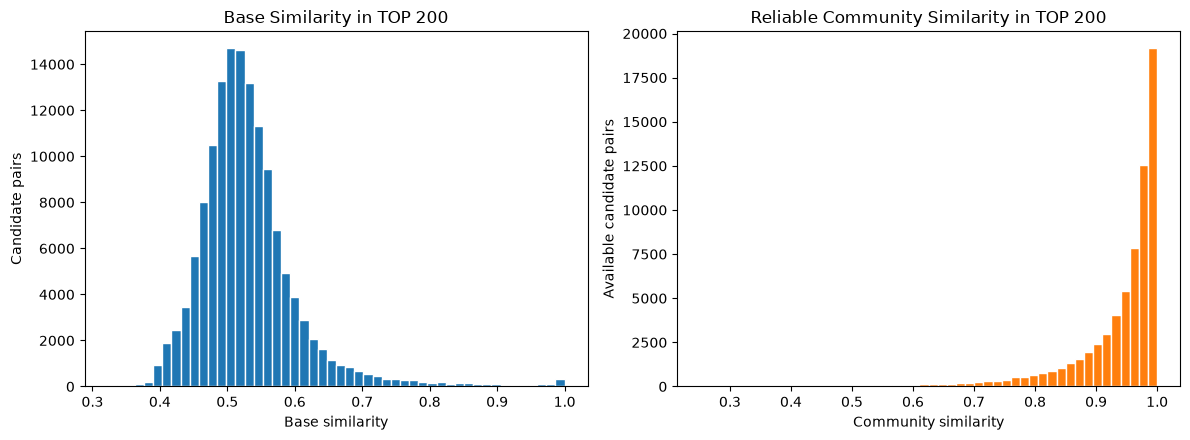

이번 Notebook에서는 두 점수의 scale을 진단만 하며 새로운 normalization은 적용하지 않는다.

In [10]:
base_scale_values = np.concatenate([
    base_top_1000_scores[int(q)][:200] for q in development_query_ids
])
community_scale_values = np.concatenate([
    community_top_1000[int(q)][:200] for q in development_query_ids
])
community_scale_values = community_scale_values[np.isfinite(community_scale_values)]

def scale_statistics(name, values):
    return {
        "score": name,
        "count": len(values),
        "mean": np.mean(values),
        "std": np.std(values, ddof=1),
        "min": np.min(values),
        "10%": np.quantile(values, 0.10),
        "25%": np.quantile(values, 0.25),
        "median": np.median(values),
        "75%": np.quantile(values, 0.75),
        "90%": np.quantile(values, 0.90),
        "max": np.max(values),
    }

score_scale_df = pd.DataFrame([
    scale_statistics("Base Similarity", base_scale_values),
    scale_statistics("Community Similarity (available only)", community_scale_values),
])
display(score_scale_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(base_scale_values, bins=50, edgecolor="white")
axes[0].set_title("Base Similarity in TOP 200")
axes[0].set_xlabel("Base similarity")
axes[0].set_ylabel("Candidate pairs")
axes[1].hist(community_scale_values, bins=50, edgecolor="white", color="tab:orange")
axes[1].set_title("Reliable Community Similarity in TOP 200")
axes[1].set_xlabel("Community similarity")
axes[1].set_ylabel("Available candidate pairs")
plt.tight_layout()
plt.show()
display(Markdown("이번 Notebook에서는 두 점수의 scale을 진단만 하며 새로운 normalization은 적용하지 않는다."))

## 12. Candidate Pool 안의 Community Coverage

In [11]:
coverage_rows = []
for pool in CANDIDATE_POOLS:
    season_flags = np.concatenate([season_available[int(q)][:pool] for q in development_query_ids])
    daypart_flags = np.concatenate([daypart_available[int(q)][:pool] for q in development_query_ids])
    coverage_rows.append({
        "candidate_pool": int(pool),
        "Season Reliable available": season_flags.mean(),
        "Daypart Reliable available": daypart_flags.mean(),
        "Season or Daypart available": (season_flags | daypart_flags).mean(),
        "Both unavailable": (~season_flags & ~daypart_flags).mean(),
    })
candidate_coverage_df = pd.DataFrame(coverage_rows)
display(candidate_coverage_df.round(4))

,candidate_pool,Season Reliable available,Daypart Reliable available,Season or Daypart available,Both unavailable
0,50,0.4790,0.3682,0.4794,0.5206
1,100,0.4768,0.3673,0.4774,0.5226
2,200,0.4750,0.3653,0.4755,0.5245
3,500,0.4707,0.3621,0.4713,0.5287
4,1000,0.4695,0.3607,0.4701,0.5299


## 13. Candidate Pool × Gamma Grid

Community similarity가 존재하면

\[
rerank=(1-\gamma)\cdot base+\gamma\cdot community
\]

를 사용한다. NaN Candidate는 gamma와 무관하게 Base score를 유지한다. Candidate Pool은 Base TOP 1000의 prefix를 재사용한다.

In [12]:
def ranking_for_config(query_id, pool, gamma, keep=20):
    query_id, pool, gamma = int(query_id), int(pool), float(gamma)
    candidates = base_top_1000[query_id][:pool]
    base_scores = base_top_1000_scores[query_id][:pool]
    community_scores = community_top_1000[query_id][:pool]
    available = np.isfinite(community_scores)
    scores = base_scores.copy()
    scores[available] = (
        (1.0 - gamma) * base_scores[available]
        + gamma * community_scores[available]
    )
    order = np.lexsort((perfume_ids[candidates], -scores))
    return candidates[order[:keep]]

grid_per_query = {}
grid_fold_results = {}
grid_rows = []

for pool in tqdm(CANDIDATE_POOLS, desc="Pool × gamma grid", mininterval=1.0):
    for gamma in GAMMAS:
        rankings = {
            int(q): ranking_for_config(int(q), int(pool), float(gamma), keep=20)
            for q in development_query_ids
        }
        detail = per_query_table(rankings)
        fold_df, means, stds = fold_summary(detail)
        key = (int(pool), float(gamma))
        grid_per_query[key] = detail
        grid_fold_results[key] = fold_df
        grid_rows.append({
            "candidate_pool": int(pool),
            "gamma": float(gamma),
            **{f"{metric} mean": means[metric] for metric in REPORT_METRICS},
            **{f"{metric} std": stds[metric] for metric in REPORT_METRICS},
        })

grid_results_df = pd.DataFrame(grid_rows)
display(grid_results_df.round(4))


Pool × gamma grid:   0%|          | 0/5 [00:00<?, ?it/s]


Pool × gamma grid:  40%|████      | 2/5 [00:01<00:02,  1.44it/s]


Pool × gamma grid:  80%|████████  | 4/5 [00:03<00:00,  1.09it/s]


Pool × gamma grid: 100%|██████████| 5/5 [00:05<00:00,  1.14s/it]

,candidate_pool,gamma,Recall@10 mean,HitRate@10 mean,MRR@10 mean,NDCG@10 mean,Recall@20 mean,NDCG@20 mean,Recall@10 std,HitRate@10 std,MRR@10 std,NDCG@10 std,Recall@20 std,NDCG@20 std
0,50,0.00,0.3010,0.5657,0.3813,0.2709,0.3500,0.2886,0.0289,0.0533,0.0200,0.0160,0.0229,0.0140
1,50,0.05,0.3075,0.5700,0.3906,0.2786,0.3646,0.2993,0.0280,0.0538,0.0224,0.0151,0.0210,0.0120
2,50,0.10,0.3153,0.5800,0.4004,0.2859,0.3746,0.3075,0.0257,0.0475,0.0183,0.0142,0.0250,0.0125
3,50,0.15,0.3250,0.5871,0.4043,0.2920,0.3799,0.3124,0.0238,0.0415,0.0159,0.0126,0.0248,0.0122
4,50,0.20,0.3316,0.6000,0.4108,0.2977,0.3838,0.3170,0.0230,0.0426,0.0155,0.0122,0.0243,0.0123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,1000,0.80,0.3396,0.6071,0.4391,0.3183,0.3893,0.3358,0.0155,0.0331,0.0207,0.0138,0.0218,0.0162
101,1000,0.85,0.3345,0.5971,0.4318,0.3119,0.3838,0.3289,0.0196,0.0366,0.0229,0.0156,0.0227,0.0173
102,1000,0.90,0.3145,0.5700,0.4218,0.2987,0.3694,0.3172,0.0201,0.0340,0.0187,0.0164,0.0128,0.0145
103,1000,0.95,0.2765,0.5357,0.3933,0.2665,0.3187,0.2806,0.0147,0.0272,0.0211,0.0180,0.0112,0.0171


## 14. NDCG@10 / Recall@10 Heatmap

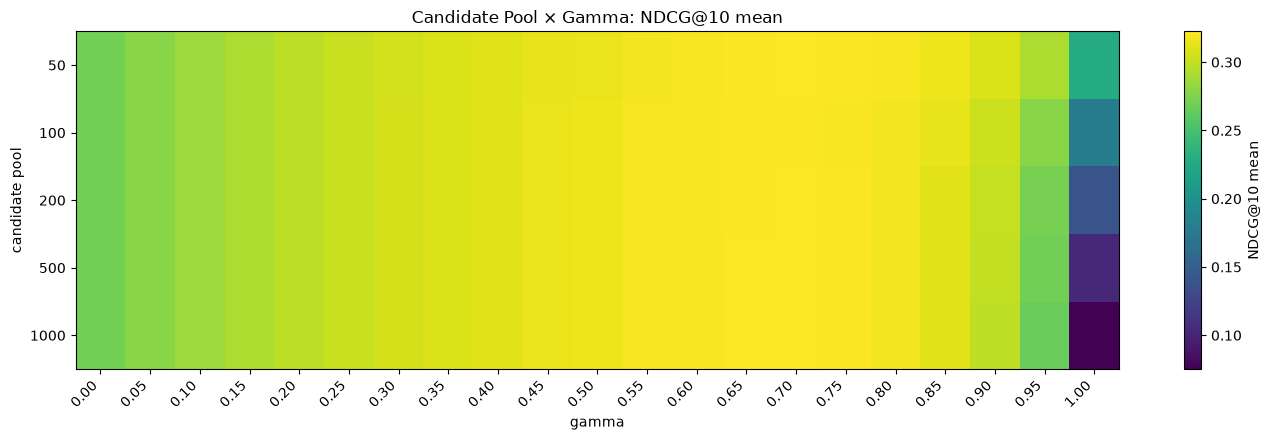

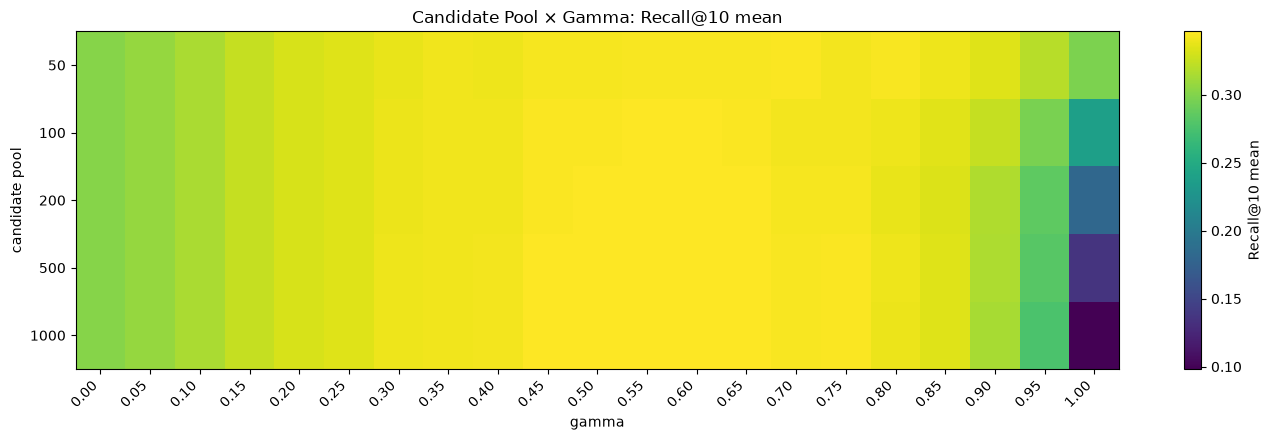

In [13]:
def draw_heatmap(metric, title):
    pivot = grid_results_df.pivot(index="candidate_pool", columns="gamma", values=metric).reindex(
        index=CANDIDATE_POOLS, columns=GAMMAS
    )
    fig, ax = plt.subplots(figsize=(14, 4.5))
    image = ax.imshow(pivot.values, aspect="auto", cmap="viridis", origin="upper")
    ax.set_xticks(np.arange(len(GAMMAS)), [f"{x:.2f}" for x in GAMMAS], rotation=45, ha="right")
    ax.set_yticks(np.arange(len(CANDIDATE_POOLS)), CANDIDATE_POOLS)
    ax.set_xlabel("gamma")
    ax.set_ylabel("candidate pool")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label=metric)
    plt.tight_layout()
    plt.show()

draw_heatmap("NDCG@10 mean", "Candidate Pool × Gamma: NDCG@10 mean")
draw_heatmap("Recall@10 mean", "Candidate Pool × Gamma: Recall@10 mean")

## 15. Candidate Pool별 최적 Gamma

In [14]:
best_by_pool_rows = []
for pool in CANDIDATE_POOLS:
    part = grid_results_df[grid_results_df["candidate_pool"] == pool]
    best = part.sort_values(
        ["NDCG@10 mean", "Recall@10 mean", "MRR@10 mean", "gamma"],
        ascending=[False, False, False, True],
    ).iloc[0]
    best_by_pool_rows.append({
        "candidate_pool": int(pool),
        "best_gamma": best["gamma"],
        **{metric: best[f"{metric} mean"] for metric in REPORT_METRICS},
    })
best_by_pool_df = pd.DataFrame(best_by_pool_rows)
display(best_by_pool_df.round(4))

,candidate_pool,best_gamma,Recall@10,HitRate@10,MRR@10,NDCG@10,Recall@20,NDCG@20
0,50,0.7,0.3456,0.6114,0.4452,0.3226,0.3903,0.3383
1,100,0.7,0.3426,0.6086,0.4448,0.3215,0.3907,0.3391
2,200,0.7,0.3433,0.6114,0.4453,0.3218,0.3915,0.3396
3,500,0.7,0.3443,0.6129,0.4457,0.3223,0.3925,0.3400
4,1000,0.7,0.3443,0.6129,0.4457,0.3223,0.3922,0.3399


## 16. Global Best와 기존 07 설정 비교

In [15]:
global_best_row = grid_results_df.sort_values(
    ["NDCG@10 mean", "Recall@10 mean", "MRR@10 mean", "candidate_pool", "gamma"],
    ascending=[False, False, False, True, True],
).iloc[0]
best_pool = int(global_best_row["candidate_pool"])
best_gamma = float(global_best_row["gamma"])
print("Development CV 기준 최고 성능 설정")
display(pd.Series({
    "Candidate Pool": best_pool,
    "Gamma": best_gamma,
    **{metric: global_best_row[f"{metric} mean"] for metric in REPORT_METRICS},
}).to_frame("값"))

current_row = grid_results_df[
    (grid_results_df["candidate_pool"] == 200) & np.isclose(grid_results_df["gamma"], 0.5)
].iloc[0]

configuration_comparison_df = pd.DataFrame([
    {"model": "A. Base Only", "candidate_pool": 1000, "gamma": 0.0,
     **{metric: base_means[metric] for metric in REPORT_METRICS}},
    {"model": "B. 07 Current Candidate", "candidate_pool": 200, "gamma": 0.5,
     **{metric: current_row[f"{metric} mean"] for metric in REPORT_METRICS}},
    {"model": "C. 08 Best Candidate", "candidate_pool": best_pool, "gamma": best_gamma,
     **{metric: global_best_row[f"{metric} mean"] for metric in REPORT_METRICS}},
])
display(configuration_comparison_df.round(4))

c_minus_b_df = pd.DataFrame([{
    "comparison": "C - B",
    **{metric: global_best_row[f"{metric} mean"] - current_row[f"{metric} mean"] for metric in REPORT_METRICS},
}])
display(c_minus_b_df.round(4))

Development CV 기준 최고 성능 설정


,값
Candidate Pool,50.000000
Gamma,0.700000
Recall@10,0.345611
HitRate@10,0.611429
MRR@10,0.445213
NDCG@10,0.322559
Recall@20,0.390343
NDCG@20,0.338295


,model,candidate_pool,gamma,Recall@10,HitRate@10,MRR@10,NDCG@10,Recall@20,NDCG@20
0,A. Base Only,1000,0.0,0.3010,0.5657,0.3813,0.2709,0.3500,0.2886
1,B. 07 Current Candidate,200,0.5,0.3457,0.6186,0.4341,0.3164,0.4013,0.3365
2,C. 08 Best Candidate,50,0.7,0.3456,0.6114,0.4452,0.3226,0.3903,0.3383


,comparison,Recall@10,HitRate@10,MRR@10,NDCG@10,Recall@20,NDCG@20
0,C - B,-0.0001,-0.0071,0.0111,0.0062,-0.011,0.0018


## 17. Efficiency Candidate

In [16]:
global_best_ndcg = float(global_best_row["NDCG@10 mean"])
efficient_options = grid_results_df[
    global_best_ndcg - grid_results_df["NDCG@10 mean"] <= PRACTICAL_TOLERANCE + 1e-12
]
efficient_pool = int(efficient_options["candidate_pool"].min())
efficiency_row = efficient_options[efficient_options["candidate_pool"] == efficient_pool].sort_values(
    ["NDCG@10 mean", "Recall@10 mean", "MRR@10 mean", "gamma"],
    ascending=[False, False, False, True],
).iloc[0]

efficiency_comparison_df = pd.DataFrame([
    {"configuration": "Global Best", "candidate_pool": best_pool, "gamma": best_gamma,
     "Recall@10": global_best_row["Recall@10 mean"], "NDCG@10": global_best_ndcg,
     "difference_from_best": 0.0},
    {"configuration": "Efficiency Candidate", "candidate_pool": int(efficiency_row["candidate_pool"]),
     "gamma": efficiency_row["gamma"], "Recall@10": efficiency_row["Recall@10 mean"],
     "NDCG@10": efficiency_row["NDCG@10 mean"],
     "difference_from_best": efficiency_row["NDCG@10 mean"] - global_best_ndcg},
])
display(efficiency_comparison_df.round(4))
display(Markdown(
    f"절대 {PRACTICAL_TOLERANCE:.3f} 이내 기준은 계산량과 성능을 함께 보기 위한 practical tolerance이며 "
    "통계적 기준이 아니다."
))

,configuration,candidate_pool,gamma,Recall@10,NDCG@10,difference_from_best
0,Global Best,50,0.7,0.3456,0.3226,0.0
1,Efficiency Candidate,50,0.7,0.3456,0.3226,0.0


절대 0.002 이내 기준은 계산량과 성능을 함께 보기 위한 practical tolerance이며 통계적 기준이 아니다.

## 18. Candidate Pool 증가 효과

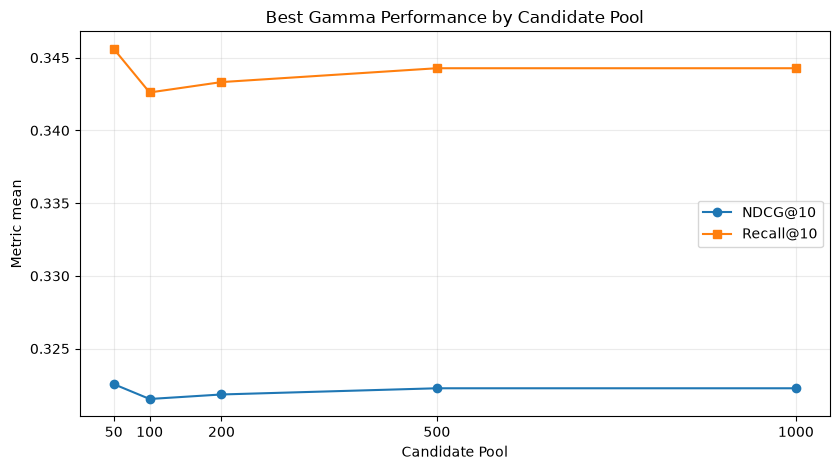

In [17]:
fig, ax1 = plt.subplots(figsize=(8.5, 4.8))
ax1.plot(best_by_pool_df["candidate_pool"], best_by_pool_df["NDCG@10"], marker="o", label="NDCG@10")
ax1.plot(best_by_pool_df["candidate_pool"], best_by_pool_df["Recall@10"], marker="s", label="Recall@10")
ax1.set_xlabel("Candidate Pool")
ax1.set_ylabel("Metric mean")
ax1.set_title("Best Gamma Performance by Candidate Pool")
ax1.set_xticks(CANDIDATE_POOLS)
ax1.grid(alpha=0.25)
ax1.legend()
plt.tight_layout()
plt.show()

## 19. Gamma Curve

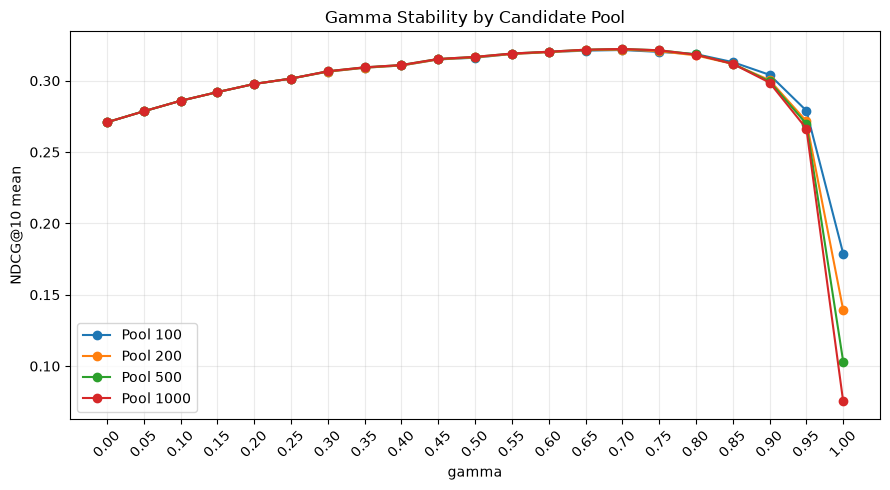

In [18]:
plt.figure(figsize=(9, 5))
for pool in (100, 200, 500, 1000):
    part = grid_results_df[grid_results_df["candidate_pool"] == pool]
    plt.plot(part["gamma"], part["NDCG@10 mean"], marker="o", label=f"Pool {pool}")
plt.xlabel("gamma")
plt.ylabel("NDCG@10 mean")
plt.title("Gamma Stability by Candidate Pool")
plt.xticks(GAMMAS, rotation=45)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 20. Fold Stability: 08 Best - 07 Current

In [19]:
current_key = (200, 0.5)
best_key = (best_pool, best_gamma)
current_per_query = grid_per_query[current_key]
best_per_query = grid_per_query[best_key]
current_fold_df = grid_fold_results[current_key]
best_fold_df = grid_fold_results[best_key]

fold_metrics = ["Recall@10", "HitRate@10", "MRR@10", "NDCG@10"]
fold_difference_df = best_fold_df[["fold", *fold_metrics]].copy()
fold_difference_df[fold_metrics] = best_fold_df[fold_metrics] - current_fold_df[fold_metrics]
display(fold_difference_df.round(4))

fold_direction_df = pd.DataFrame([
    {
        "metric": metric,
        "개선 Fold 수": int((fold_difference_df[metric] > 1e-12).sum()),
        "하락 Fold 수": int((fold_difference_df[metric] < -1e-12).sum()),
        "동일 Fold 수": int((np.abs(fold_difference_df[metric]) <= 1e-12).sum()),
    }
    for metric in fold_metrics
])
display(fold_direction_df)

,fold,Recall@10,HitRate@10,MRR@10,NDCG@10
0,1,0.0020,-0.0214,0.0084,0.0038
1,2,0.0090,0.0143,0.0060,0.0060
2,3,-0.0088,-0.0143,-0.0035,-0.0020
3,4,0.0061,0.0000,0.0288,0.0173
4,5,-0.0086,-0.0143,0.0158,0.0057


,metric,개선 Fold 수,하락 Fold 수,동일 Fold 수
0,Recall@10,3,2,0
1,HitRate@10,1,3,1
2,MRR@10,4,1,0
3,NDCG@10,4,1,0


## 21. Paired Bootstrap: 추가 튜닝의 안정성

In [20]:
bootstrap_rng = np.random.default_rng(SEED)
bootstrap_rows = []
for metric in ("Recall@10", "NDCG@10"):
    current_values = current_per_query.set_index("query_id").loc[development_query_ids, metric].to_numpy()
    best_values = best_per_query.set_index("query_id").loc[development_query_ids, metric].to_numpy()
    differences = best_values - current_values
    indices = bootstrap_rng.integers(0, len(differences), size=(BOOTSTRAP_RESAMPLES, len(differences)))
    bootstrap_means = differences[indices].mean(axis=1)
    lower, upper = np.quantile(bootstrap_means, [0.025, 0.975])
    bootstrap_rows.append({
        "metric": metric,
        "mean_difference": differences.mean(),
        "ci_2.5%": lower,
        "ci_97.5%": upper,
        "CI_includes_zero": bool(lower <= 0 <= upper),
        "improvement_direction_stability": (
            "추가 튜닝의 개선 방향이 안정적" if lower > 0
            else "추가 튜닝의 하락 방향이 안정적" if upper < 0
            else "CI가 0을 포함해 추가 튜닝 방향이 안정적이지 않음"
        ),
    })
bootstrap_df = pd.DataFrame(bootstrap_rows)
display(bootstrap_df.round(4))

,metric,mean_difference,ci_2.5%,ci_97.5%,CI_includes_zero,improvement_direction_stability
0,Recall@10,-0.0001,-0.0075,0.0074,True,CI가 0을 포함해 추가 튜닝 방향이 안정적이지 않음
1,NDCG@10,0.0062,0.0013,0.0111,False,추가 튜닝의 개선 방향이 안정적


## 22. Popularity Robustness

In [21]:
popularity_frame = pd.DataFrame({
    "query_id": development_query_ids.astype(int),
    "popularity": popularity[development_rows],
}).dropna()

popularity_robustness_df = pd.DataFrame()
if popularity_frame["popularity"].nunique() >= 4:
    try:
        popularity_frame["quartile"] = pd.qcut(
            popularity_frame["popularity"], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="raise"
        )
        rows = []
        for quartile in ["Q1", "Q2", "Q3", "Q4"]:
            ids = popularity_frame.loc[popularity_frame["quartile"] == quartile, "query_id"].astype(int)
            row = {"popularity_quartile": quartile, "query_count": len(ids)}
            for label, detail in (("07 Current", current_per_query), ("08 Best", best_per_query)):
                part = detail[detail["query_id"].isin(ids)]
                row[f"{label} Recall@10"] = part["Recall@10"].mean()
                row[f"{label} NDCG@10"] = part["NDCG@10"].mean()
            rows.append(row)
        popularity_robustness_df = pd.DataFrame(rows)
        display(popularity_robustness_df.round(4))
    except ValueError as exc:
        print(f"4분위 생성 불가: {exc}")
else:
    print("고유 popularity 값이 4개 미만이라 분석하지 않습니다.")

,popularity_quartile,query_count,07 Current Recall@10,07 Current NDCG@10,08 Best Recall@10,08 Best NDCG@10
0,Q1,175,0.3486,0.3002,0.3526,0.3061
1,Q2,175,0.3158,0.2670,0.3112,0.2667
2,Q3,175,0.3217,0.2988,0.3214,0.3067
3,Q4,175,0.3966,0.3996,0.3972,0.4107


## 23. Ranking 변화 사례

In [22]:
def full_ranking_for_config(query_id, pool, gamma):
    return ranking_for_config(query_id, pool, gamma, keep=pool)

def pair_scores(query_id, relevant_id):
    candidates = base_top_1000[int(query_id)]
    positions = np.flatnonzero(perfume_ids[candidates] == int(relevant_id))
    if not len(positions):
        return np.nan, np.nan
    pos = int(positions[0])
    return base_top_1000_scores[int(query_id)][pos], community_top_1000[int(query_id)][pos]

def rank_label(rank, pool):
    return rank if rank is not None else f">{pool}"

case_records = []
for query_id in development_query_ids:
    query_id = int(query_id)
    current_ranking = full_ranking_for_config(query_id, 200, 0.5)
    best_ranking = full_ranking_for_config(query_id, best_pool, best_gamma)
    current_ranks = {int(perfume_ids[row]): i for i, row in enumerate(current_ranking, start=1)}
    best_ranks = {int(perfume_ids[row]): i for i, row in enumerate(best_ranking, start=1)}
    for relevant_id in relevant_by_query[query_id]:
        relevant_id = int(relevant_id)
        rank_07 = current_ranks.get(relevant_id)
        rank_08 = best_ranks.get(relevant_id)
        censored = False
        if rank_07 is not None and rank_08 is not None:
            difference = rank_07 - rank_08
        elif rank_07 is None and rank_08 is not None and rank_08 <= 200:
            # 07 rank > 200이므로 최소 개선폭만 계산할 수 있다.
            difference = 201 - rank_08
            censored = True
        elif rank_07 is not None and rank_08 is None and best_pool >= rank_07:
            # 08 rank > best_pool이므로 최소 하락폭만 계산할 수 있다.
            difference = rank_07 - (best_pool + 1)
            censored = True
        else:
            # 두 censored rank의 대소관계를 확정할 수 없는 pair는 사례 표에서 제외한다.
            continue
        if difference == 0:
            continue
        base_similarity, community_similarity = pair_scores(query_id, relevant_id)
        query_row, relevant_row = id_to_row[query_id], id_to_row[relevant_id]
        case_records.append({
            "direction": "improved" if difference > 0 else "harmed",
            "sort_difference": difference,
            "query perfume": perfume_names[query_row],
            "brand": perfume_brands[query_row],
            "relevant perfume": perfume_names[relevant_row],
            "07 rank": rank_label(rank_07, 200),
            "08 rank": rank_label(rank_08, best_pool),
            "rank improvement": difference,
            "base similarity": base_similarity,
            "community similarity": community_similarity,
            "rank_is_censored": censored,
        })

cases_df = pd.DataFrame(case_records)
display(Markdown("### 08 Best가 순위를 개선한 사례 (최대 10개)"))
if len(cases_df) and (cases_df["direction"] == "improved").any():
    display(cases_df[cases_df["direction"] == "improved"].sort_values(
        ["sort_difference", "query perfume"], ascending=[False, True]
    ).drop(columns=["direction", "sort_difference"]).head(10).round(4))
else:
    print("해당 사례가 없습니다.")

display(Markdown("### 08 Best에서 순위가 하락한 사례 (최대 10개)"))
if len(cases_df) and (cases_df["direction"] == "harmed").any():
    display(cases_df[cases_df["direction"] == "harmed"].sort_values(
        ["sort_difference", "query perfume"], ascending=[True, True]
    ).drop(columns=["direction", "sort_difference"]).head(10).round(4))
else:
    print("해당 사례가 없습니다.")

display(Markdown(
    "Relevant Item이 비교하는 pool 밖이면 rank를 `>N`으로 표시했다. 이 경우 `rank improvement`는 "
    "확정 가능한 최소 변화폭이며 `rank_is_censored=True`로 구분한다. 두 censored rank의 대소관계를 "
    "확정할 수 없는 pair는 사례 표에서 제외했다."
))

### 08 Best가 순위를 개선한 사례 (최대 10개)

,query perfume,brand,relevant perfume,07 rank,08 rank,rank improvement,base similarity,community similarity,rank_is_censored
638,Herod,Parfums de Marly,Majestueux,116,31,85,0.6490,NaN,False
485,Cotton Candy Girly Girl,Prince Matchabelli,Egeo Dolce,115,32,83,0.6118,0.6715,False
65,Vanilla Hope,We Pink,Summer Sun,111,28,83,0.5963,0.8480,False
203,L'Heure Bleue Eau de Toilette,Guerlain,L'Heure Bleue Yves Klein Edition,111,32,79,0.5836,NaN,False
16,Sole di Positano,Tom Ford,Soul of Amalfi,111,32,79,0.7541,NaN,False
281,Oranger Alhambra,Giorgio Armani,Cologne 1888,108,33,75,0.6509,NaN,False
573,Amore Caffè,Mancera,Café Arabica,99,27,72,0.6550,NaN,False
70,Feminité du Bois,Serge Lutens,Shiraz,93,26,67,0.5798,0.8461,False
601,Floral Bloom,Maison Alhambra,Mysterious Girl,96,29,67,0.5620,0.8805,False
589,Vetiver Root,Korres,La Nuit de l'Homme,92,25,67,0.5508,0.8872,False


### 08 Best에서 순위가 하락한 사례 (최대 10개)

,query perfume,brand,relevant perfume,07 rank,08 rank,rank improvement,base similarity,community similarity,rank_is_censored
595,Glow,Jennifer Lopez,Eau de Glow,7,>50,-44,0.6144,0.9985,True
462,4 Rue Scribe,Maïssa Parfums,Aqua Allegoria Granada Salvia,10,>50,-41,0.5192,0.9941,True
517,Blueberry Sugar Pancakes,Bath & Body Works,Blueberry Bundt Cake,10,>50,-41,0.5017,0.9974,True
254,Miss Dior Parfum,Dior,Miss Dior Original Extrait de Parfum,10,>50,-41,0.5120,0.9925,True
632,This is Not GABA,Hormone Paris,Akigala Mandarino,10,>50,-41,0.5200,0.9886,True
423,Taskeen Lactéa Divina,PARIS CORNER,Her Confession,11,>50,-40,0.5114,0.9984,True
29,Boardwalk Taffy,Bath & Body Works,Cotton Candy Clouds,12,>50,-39,0.6097,0.9443,True
312,Elixir Floral,Câline,Delina,12,>50,-39,0.5845,0.9977,True
232,MYSLF L’Absolu,Yves Saint Laurent,Narcisus,12,>50,-39,0.5326,0.9947,True
539,The Tux,Maison Alhambra,Turathi Brown,12,>50,-39,0.5398,0.9927,True


Relevant Item이 비교하는 pool 밖이면 rank를 `>N`으로 표시했다. 이 경우 `rank improvement`는 확정 가능한 최소 변화폭이며 `rank_is_censored=True`로 구분한다. 두 censored rank의 대소관계를 확정할 수 없는 pair는 사례 표에서 제외했다.

## 24. Boundary Check

In [23]:
gamma_boundary = bool(np.isclose(best_gamma, 0.0) or np.isclose(best_gamma, 1.0))
pool_boundary = best_pool == int(CANDIDATE_POOLS.max())

if gamma_boundary:
    print("최적 gamma가 탐색 경계에 위치합니다. 현재 raw similarity scale 또는 결합 방식에 대한 추가 검토가 필요할 수 있습니다.")
    print("gamma는 convex combination의 전체 범위 0~1을 이미 탐색했으므로 자동 확장하지 않습니다.")
else:
    print("최적 gamma는 탐색 경계에 위치하지 않습니다.")

if pool_boundary:
    print("Candidate Pool 최적값이 현재 탐색 범위의 상한입니다.")
    print("2000 등으로 자동 확장하지 않고 Candidate Recall과 성능 포화 정도를 다음 단계에서 판단합니다.")
else:
    print("최적 Candidate Pool은 현재 탐색 범위의 상한이 아닙니다.")

최적 gamma는 탐색 경계에 위치하지 않습니다.
최적 Candidate Pool은 현재 탐색 범위의 상한이 아닙니다.


## 25. 결과 해석

In [24]:
metric_difference = {
    metric: float(global_best_row[f"{metric} mean"] - current_row[f"{metric} mean"])
    for metric in REPORT_METRICS
}
improved_ndcg_folds = int((fold_difference_df["NDCG@10"] > 0).sum())
bootstrap_lookup = bootstrap_df.set_index("metric")
recall_ci = bootstrap_lookup.loc["Recall@10"]
ndcg_ci = bootstrap_lookup.loc["NDCG@10"]

case_a = (
    metric_difference["NDCG@10"] > PRACTICAL_TOLERANCE
    and improved_ndcg_folds >= 3
    and ndcg_ci["ci_2.5%"] > 0
)
case_b = (
    abs(metric_difference["NDCG@10"]) <= PRACTICAL_TOLERANCE
    or bool(ndcg_ci["CI_includes_zero"])
)

if case_a:
    conclusion = "Community Reranking의 가중치 또는 Candidate Pool 조정이 추가적인 성능 개선을 제공했다."
elif case_b:
    conclusion = "기존 pool=200, gamma=0.5 설정이 이미 충분히 안정적이며 추가 Hyperparameter tuning의 실익이 제한적이다."
else:
    conclusion = "추가 tuning 결과가 일부 지표에서는 변하지만 일관된 개선이라고 판단하기 어렵다."

boundary_interpretation = ""
if np.isclose(best_gamma, 1.0):
    boundary_interpretation = (
        " Best gamma=1.0이므로 Base Candidate Retrieval은 필요하지만 TOP-N 후보 내 Ranking에서는 "
        "Community Score의 비중이 매우 강하게 작동했다. 향 구조 정보가 필요 없다는 뜻은 아니다. "
        "후보 자체가 Base Accord + Notes로 생성되었기 때문이다."
    )

ceiling_for_interpretation = candidate_ceiling_df.set_index("candidate_pool")
pool50_ceiling = ceiling_for_interpretation.loc[50, "CandidateRecall"]
pool200_ceiling = ceiling_for_interpretation.loc[200, "CandidateRecall"]

display(Markdown(f"""
### Development Benchmark 판단

{conclusion}{boundary_interpretation}

Global Best와 07 Current의 NDCG@10 차이는 **{metric_difference['NDCG@10']:+.4f}**다. Candidate Recall ceiling, Fold 방향, paired bootstrap을 함께 보고 해석하며 단순 최고값만으로 최종 모델을 확정하지 않는다.

다만 Recall@10 변화는 **{metric_difference['Recall@10']:+.4f}**, Recall@20 변화는 **{metric_difference['Recall@20']:+.4f}**다. Candidate Recall도 pool 200의 **{pool200_ceiling:.4f}**에서 pool 50의 **{pool50_ceiling:.4f}**로 낮아진다. 즉 이번 이득은 전체 Relevant Item 확보량보다 TOP 10 안의 순서 품질(MRR/NDCG) 개선에 더 가깝고, 검색 폭 감소라는 trade-off가 있다.
"""))


### Development Benchmark 판단

Community Reranking의 가중치 또는 Candidate Pool 조정이 추가적인 성능 개선을 제공했다.

Global Best와 07 Current의 NDCG@10 차이는 **+0.0062**다. Candidate Recall ceiling, Fold 방향, paired bootstrap을 함께 보고 해석하며 단순 최고값만으로 최종 모델을 확정하지 않는다.

다만 Recall@10 변화는 **-0.0001**, Recall@20 변화는 **-0.0110**다. Candidate Recall도 pool 200의 **0.5118**에서 pool 50의 **0.4151**로 낮아진다. 즉 이번 이득은 전체 Relevant Item 확보량보다 TOP 10 안의 순서 품질(MRR/NDCG) 개선에 더 가깝고, 검색 폭 감소라는 trade-off가 있다.


## 26. 최종 요약

In [25]:
ceiling_lookup = candidate_ceiling_df.set_index("candidate_pool")
scale_lookup = score_scale_df.set_index("score")
current_metrics = {metric: float(current_row[f"{metric} mean"]) for metric in REPORT_METRICS}
best_metrics = {metric: float(global_best_row[f"{metric} mean"]) for metric in REPORT_METRICS}

gamma_boundary_text = "예" if gamma_boundary else "아니오"
pool_boundary_text = "예 (상한 1000)" if pool_boundary else "아니오"
calibration_needed = (
    "예 — Base와 Community의 raw score scale 차이가 커 후속 calibration 진단 가치가 있음; 이번 Notebook에서는 미적용"
    if abs(scale_lookup.loc['Community Similarity (available only)', 'mean'] - scale_lookup.loc['Base Similarity', 'mean']) > 0.2
    else "현재 scale 차이는 제한적이며 normalization은 이번 Notebook에서 적용하지 않음"
)
structure_fixed = (
    "아직 보류 — 경계 또는 Candidate Pool 상한을 다음 단계에서 검토" if gamma_boundary or pool_boundary
    else "후보 설정으로 유지하되 검색 폭·Recall@20 trade-off와 score scale을 검토한 뒤 고정; Final Holdout 검증 전"
)

summary_markdown = f"""
## Candidate Retrieval Ceiling

TOP 50:
- Candidate Recall: **{ceiling_lookup.loc[50, 'CandidateRecall']:.4f}**
- Candidate HitRate: **{ceiling_lookup.loc[50, 'CandidateHitRate']:.4f}**

TOP 100:
- Candidate Recall: **{ceiling_lookup.loc[100, 'CandidateRecall']:.4f}**
- Candidate HitRate: **{ceiling_lookup.loc[100, 'CandidateHitRate']:.4f}**

TOP 200:
- Candidate Recall: **{ceiling_lookup.loc[200, 'CandidateRecall']:.4f}**
- Candidate HitRate: **{ceiling_lookup.loc[200, 'CandidateHitRate']:.4f}**

TOP 500:
- Candidate Recall: **{ceiling_lookup.loc[500, 'CandidateRecall']:.4f}**
- Candidate HitRate: **{ceiling_lookup.loc[500, 'CandidateHitRate']:.4f}**

TOP 1000:
- Candidate Recall: **{ceiling_lookup.loc[1000, 'CandidateRecall']:.4f}**
- Candidate HitRate: **{ceiling_lookup.loc[1000, 'CandidateHitRate']:.4f}**

## Score Scale

Base Similarity:
- mean: **{scale_lookup.loc['Base Similarity', 'mean']:.4f}**
- median: **{scale_lookup.loc['Base Similarity', 'median']:.4f}**
- std: **{scale_lookup.loc['Base Similarity', 'std']:.4f}**

Community Similarity:
- mean: **{scale_lookup.loc['Community Similarity (available only)', 'mean']:.4f}**
- median: **{scale_lookup.loc['Community Similarity (available only)', 'median']:.4f}**
- std: **{scale_lookup.loc['Community Similarity (available only)', 'std']:.4f}**

## Existing Configuration

- Candidate Pool: **200**
- gamma: **0.5**
- Recall@10: **{current_metrics['Recall@10']:.4f}**
- HitRate@10: **{current_metrics['HitRate@10']:.4f}**
- MRR@10: **{current_metrics['MRR@10']:.4f}**
- NDCG@10: **{current_metrics['NDCG@10']:.4f}**

## Global Best

- Candidate Pool: **{best_pool}**
- gamma: **{best_gamma:.2f}**
- Recall@10: **{best_metrics['Recall@10']:.4f}**
- HitRate@10: **{best_metrics['HitRate@10']:.4f}**
- MRR@10: **{best_metrics['MRR@10']:.4f}**
- NDCG@10: **{best_metrics['NDCG@10']:.4f}**

## Efficiency Candidate

- Candidate Pool: **{int(efficiency_row['candidate_pool'])}**
- gamma: **{efficiency_row['gamma']:.2f}**
- NDCG@10: **{efficiency_row['NDCG@10 mean']:.4f}**
- Global Best와 차이: **{efficiency_row['NDCG@10 mean'] - global_best_ndcg:+.4f}**

## Stability

- 개선 Fold 수: **NDCG@10 {improved_ndcg_folds}/5**
- Recall@10 Bootstrap CI: **[{recall_ci['ci_2.5%']:.4f}, {recall_ci['ci_97.5%']:.4f}]** (0 포함: {recall_ci['CI_includes_zero']})
- NDCG@10 Bootstrap CI: **[{ndcg_ci['ci_2.5%']:.4f}, {ndcg_ci['ci_97.5%']:.4f}]** (0 포함: {ndcg_ci['CI_includes_zero']})

## Boundary

- gamma가 경계인지: **{gamma_boundary_text}**
- Candidate Pool이 경계인지: **{pool_boundary_text}**

## 현재 판단

- Candidate Pool: **Global Best {best_pool}; Efficiency Candidate {int(efficiency_row['candidate_pool'])}**
- Community gamma: **Global Best {best_gamma:.2f}**
- 07 대비 추가 튜닝 효과: **NDCG@10 {metric_difference['NDCG@10']:+.4f}, Recall@10 {metric_difference['Recall@10']:+.4f}, Recall@20 {metric_difference['Recall@20']:+.4f}; {conclusion}**
- 현재 구조를 고정할 수 있는지: **{structure_fixed}**
- Score calibration 추가 분석이 필요한지: **{calibration_needed}**
- Final Holdout은 아직 미사용인지: **예 — candidate 생성 및 평가 0건**

Final Holdout 300개는 끝까지 사용하지 않았다. 위 설정은 **Development CV 기준 최고 성능 설정**이며 최종 모델이 아니다.
"""
display(Markdown(summary_markdown))
print("Final Holdout 평가 query 수: 0")


## Candidate Retrieval Ceiling

TOP 50:
- Candidate Recall: **0.4151**
- Candidate HitRate: **0.6686**

TOP 100:
- Candidate Recall: **0.4592**
- Candidate HitRate: **0.7157**

TOP 200:
- Candidate Recall: **0.5118**
- Candidate HitRate: **0.7571**

TOP 500:
- Candidate Recall: **0.5806**
- Candidate HitRate: **0.8214**

TOP 1000:
- Candidate Recall: **0.6240**
- Candidate HitRate: **0.8486**

## Score Scale

Base Similarity:
- mean: **0.5310**
- median: **0.5203**
- std: **0.0758**

Community Similarity:
- mean: **0.9374**
- median: **0.9675**
- std: **0.0803**

## Existing Configuration

- Candidate Pool: **200**
- gamma: **0.5**
- Recall@10: **0.3457**
- HitRate@10: **0.6186**
- MRR@10: **0.4341**
- NDCG@10: **0.3164**

## Global Best

- Candidate Pool: **50**
- gamma: **0.70**
- Recall@10: **0.3456**
- HitRate@10: **0.6114**
- MRR@10: **0.4452**
- NDCG@10: **0.3226**

## Efficiency Candidate

- Candidate Pool: **50**
- gamma: **0.70**
- NDCG@10: **0.3226**
- Global Best와 차이: **+0.0000**

## Stability

- 개선 Fold 수: **NDCG@10 4/5**
- Recall@10 Bootstrap CI: **[-0.0075, 0.0074]** (0 포함: True)
- NDCG@10 Bootstrap CI: **[0.0013, 0.0111]** (0 포함: False)

## Boundary

- gamma가 경계인지: **아니오**
- Candidate Pool이 경계인지: **아니오**

## 현재 판단

- Candidate Pool: **Global Best 50; Efficiency Candidate 50**
- Community gamma: **Global Best 0.70**
- 07 대비 추가 튜닝 효과: **NDCG@10 +0.0062, Recall@10 -0.0001, Recall@20 -0.0110; Community Reranking의 가중치 또는 Candidate Pool 조정이 추가적인 성능 개선을 제공했다.**
- 현재 구조를 고정할 수 있는지: **후보 설정으로 유지하되 검색 폭·Recall@20 trade-off와 score scale을 검토한 뒤 고정; Final Holdout 검증 전**
- Score calibration 추가 분석이 필요한지: **예 — Base와 Community의 raw score scale 차이가 커 후속 calibration 진단 가치가 있음; 이번 Notebook에서는 미적용**
- Final Holdout은 아직 미사용인지: **예 — candidate 생성 및 평가 0건**

Final Holdout 300개는 끝까지 사용하지 않았다. 위 설정은 **Development CV 기준 최고 성능 설정**이며 최종 모델이 아니다.


Final Holdout 평가 query 수: 0


## Candidate Retrieval Ceiling

TOP 50:
- Candidate Recall: **0.4151**
- Candidate HitRate: **0.6686**

TOP 100:
- Candidate Recall: **0.4592**
- Candidate HitRate: **0.7157**

TOP 200:
- Candidate Recall: **0.5118**
- Candidate HitRate: **0.7571**

TOP 500:
- Candidate Recall: **0.5806**
- Candidate HitRate: **0.8214**

TOP 1000:
- Candidate Recall: **0.6240**
- Candidate HitRate: **0.8486**

## Score Scale

Base Similarity:
- mean: **0.5310**
- median: **0.5203**
- std: **0.0758**

Community Similarity:
- mean: **0.9374**
- median: **0.9675**
- std: **0.0803**

## Existing Configuration

- Candidate Pool: **200**
- gamma: **0.5**
- Recall@10: **0.3457**
- HitRate@10: **0.6186**
- MRR@10: **0.4341**
- NDCG@10: **0.3164**

## Global Best

- Candidate Pool: **50**
- gamma: **0.70**
- Recall@10: **0.3456**
- HitRate@10: **0.6114**
- MRR@10: **0.4452**
- NDCG@10: **0.3226**

## Efficiency Candidate

- Candidate Pool: **50**
- gamma: **0.70**
- NDCG@10: **0.3226**
- Global Best와 차이: **+0.0000**

## Stability

- 개선 Fold 수: **NDCG@10 4/5**
- Recall@10 Bootstrap CI: **[-0.0075, 0.0074]** (0 포함: True)
- NDCG@10 Bootstrap CI: **[0.0013, 0.0111]** (0 포함: False)

## Boundary

- gamma가 경계인지: **아니오**
- Candidate Pool이 경계인지: **아니오**

## 현재 판단

- Candidate Pool: **Global Best 50; Efficiency Candidate 50**
- Community gamma: **Global Best 0.70**
- 07 대비 추가 튜닝 효과: **NDCG@10 +0.0062, Recall@10 -0.0001, Recall@20 -0.0110; Community Reranking의 가중치 또는 Candidate Pool 조정이 추가적인 성능 개선을 제공했다.**
- 현재 구조를 고정할 수 있는지: **후보 설정으로 유지하되 검색 폭·Recall@20 trade-off와 score scale을 검토한 뒤 고정; Final Holdout 검증 전**
- Score calibration 추가 분석이 필요한지: **예 — Base와 Community의 raw score scale 차이가 커 후속 calibration 진단 가치가 있음; 이번 Notebook에서는 미적용**
- Final Holdout은 아직 미사용인지: **예 — candidate 생성 및 평가 0건**

Final Holdout 300개는 끝까지 사용하지 않았다. 위 설정은 **Development CV 기준 최고 성능 설정**이며 최종 모델이 아니다.